instead of binary cross contrastive loss

 instead of concat use difference

no dense layer (can with binary cross)


second methhod


save and try one shot learning


In [14]:
import tensorflow as tf

mnist = tf.keras.datasets.mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [15]:
from tensorflow.keras.layers import *
from tensorflow.keras.models import Sequential, Model


img_A_inp = Input((28, 28), name='img_A_inp')
img_B_inp = Input((28, 28), name='img_B_inp')

def get_cnn_block(depth):
  return Sequential([
      Conv2D(depth, 3, 1),
      BatchNormalization(),
      ReLU()
  ])

DEPTH = 64
cnn = Sequential([
    Reshape((28, 28, 1)),
    get_cnn_block(DEPTH),
    get_cnn_block(DEPTH*2),
    get_cnn_block(DEPTH*4),
    get_cnn_block(DEPTH*8),
    GlobalAveragePooling2D(),
    Dense(64, activation='relu')
])

feature_vector_A = cnn(img_A_inp)
feature_vector_B = cnn(img_B_inp)

difference = Subtract()([feature_vector_A, feature_vector_B])

dense = Dense(64, activation='relu')(difference)
output = Dense(1, activation='sigmoid')(dense)

model = Model(inputs=[img_A_inp, img_B_inp], outputs=output)

model.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ img_A_inp           │ (None, 28, 28)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img_B_inp           │ (None, 28, 28)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_9        │ (None, 64)        │  1,586,496 │ img_A_inp[0][0],  │
│ (Sequential)        │                   │            │ img_B_inp[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract_1          │ (None, 64)        │          0 │ sequential_9[0][… │
│ (Subtract)          │                   │            │ sequential_9[1][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      4,160 │ subtract_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         65 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,590,721 (6.07 MB)

 Trainable params: 1,588,801 (6.06 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [16]:
import numpy as np

random_indices = np.random.choice(X_train.shape[0], 300, replace=False)

X_train_sample, y_train_sample = X_train[random_indices], y_train[random_indices]

X_train_sample.shape, y_train_sample.shape

((300, 28, 28), (300,))

In [17]:
len(X_train_sample) ** 2

90000

In [18]:
import itertools

def make_paired_dataset(X, y):
  X_pairs, y_pairs = [], []

  tuples = [(x1, y1) for x1, y1 in zip(X, y)]

  for t in itertools.product(tuples, tuples):
    pair_A, pair_B = t
    img_A, label_A = t[0]
    img_B, label_B = t[1]

    new_label = int(label_A == label_B)

    X_pairs.append([img_A, img_B])
    y_pairs.append(new_label)

  X_pairs = np.array(X_pairs)
  y_pairs = np.array(y_pairs)

  return X_pairs, y_pairs

In [19]:
make_paired_dataset(X_train_sample, y_train_sample)

(array([[[[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
 
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]]],
 
 
        [[[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
 
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]]],
 
 
        [[[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0

In [20]:
X_train_pairs, y_train_pairs = make_paired_dataset(X_train_sample, y_train_sample)

X_train_pairs.shape, y_train_pairs.shape

((90000, 2, 28, 28), (90000,))

In [21]:
random_indices = np.random.choice(X_test.shape[0], 150, replace=False)

X_test_sample, y_test_sample = X_test[random_indices], y_test[random_indices]

X_test_sample.shape, y_test_sample.shape

((150, 28, 28), (150,))

In [22]:
X_test_pairs, y_test_pairs = make_paired_dataset(X_test_sample, y_test_sample)

X_test_pairs.shape, y_test_pairs.shape

((22500, 2, 28, 28), (22500,))

In [23]:
import tensorflow as tf

def contrastive_loss(y_true, y_pred):
    margin = 1.0
    square_pred = tf.square(y_pred)
    margin_square = tf.square(tf.maximum(margin - y_pred, 0))
    return tf.reduce_mean(y_true * square_pred + (1 - y_true) * margin_square)

model.compile(loss=contrastive_loss,
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              metrics=['accuracy'])

In [24]:
from tensorflow.keras.callbacks import EarlyStopping

es = EarlyStopping(patience=3)

In [25]:
model.fit(x=[X_train_pairs[:, 0, :, :], X_train_pairs[:, 1, :, :]],
          y=y_train_pairs,
          validation_data=([X_test_pairs[:, 0, :, :],
                            X_test_pairs[:, 1, :, :]],
                           y_test_pairs),
          epochs=300,
          batch_size=32,
          callbacks=[es])

Epoch 1/300
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 193s 64ms/step - accuracy: 0.0950 - loss: 0.0733 - val_accuracy: 0.0884 - val_loss: 0.0628
Epoch 2/300
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 182s 65ms/step - accuracy: 0.0115 - loss: 0.0097 - val_accuracy: 0.0580 - val_loss: 0.0436
Epoch 3/300
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 181s 64ms/step - accuracy: 0.0035 - loss: 0.0033 - val_accuracy: 0.0512 - val_loss: 0.0383
Epoch 4/300
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 180s 64ms/step - accuracy: 0.0024 - loss: 0.0020 - val_accuracy: 0.0399 - val_loss: 0.0309
Epoch 5/300
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 179s 64ms/step - accuracy: 0.0023 - loss: 0.0020 - val_accuracy: 0.0679 - val_loss: 0.0535
Epoch 6/300
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 179s 63ms/step - accuracy: 0.0049 - loss: 0.0041 - val_accuracy: 0.0445 - val_loss: 0.0349
Epoch 7/300
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 179s 64ms/step - accuracy: 0.0020 - loss: 0.0018 - val_accuracy: 0.0542 - val_loss: 0.0442


In [26]:
img_A, img_B = X_test[0], X_test[17]
label_A, label_B = y_test[0], y_test[17]

label_A, label_B

(np.uint8(7), np.uint8(7))

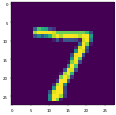

In [27]:
import matplotlib.pyplot as plt

plt.figure(dpi=28)
plt.imshow(img_A)

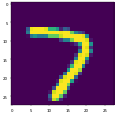

In [28]:
plt.figure(dpi=28)
plt.imshow(img_B)

In [29]:
model.predict([img_A.reshape((1, 28, 28)),
               img_B.reshape((1, 28, 28))]).flatten()[0] > 0.5

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   


np.False_

In [30]:
model.save('model2.keras')